© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

English translation managed by Tamás Takács. The translation was produced with AI assistance.

In [ ]:
# ⚠️ Data not available (Google Drive deleted)
# @title Downloading the images and the model file
# !gdown -qq 1R7_GkPvbES1TiTANJVhNVvhKFiRvCF3P
# !gdown -qq 1zP8XVsNLszjNjkCeJOnuIV48C6mWdtYZ
# !unzip -qq állatok.zip -d állatok
# !rm -rf állatok.zip


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.models as models


from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models.efficientnet import EfficientNet_B2_Weights

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

classes = {0: 'butterfly',
            1: 'cat',
            2: 'cow',
            3: 'dog',
            4: 'elephant',
            5: 'hen',
            6: 'horse',
            7: 'sheep',
            8: 'spider',
            9: 'squirrel'}

In [ ]:
model = models.efficientnet_b2(weights = EfficientNet_B2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10),
    nn.Softmax(dim=1)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 40.1MB/s]


In [ ]:
model.load_state_dict(torch.load('jános_modell.pth', map_location=torch.device('cpu')))
model = model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

In [ ]:
class SingleFolderDataset(Dataset):
    def __init__(self, directory, transform=None):
        """
        Args:
            directory (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.directory = directory
        self.transform = transform
        self.images = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        image = Image.open(img_name).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = SingleFolderDataset(directory='/content/állatok', transform=transform)
data_loader = DataLoader(dataset, batch_size=1, shuffle=False)

In [ ]:
def imshow(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:, None, None] + mean[:, None, None]
    img = img.clamp(0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')


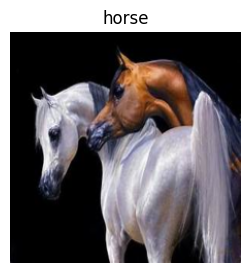

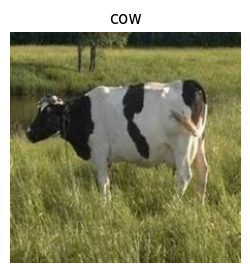

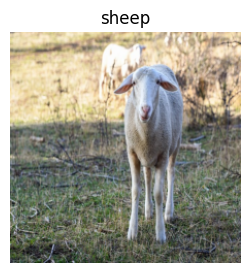

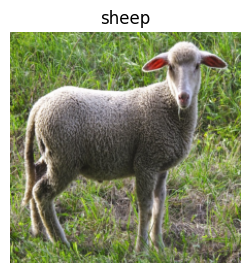

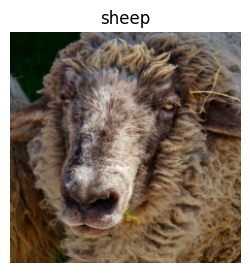

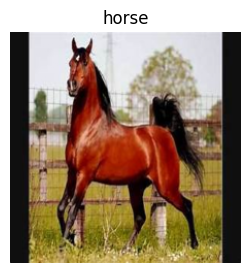

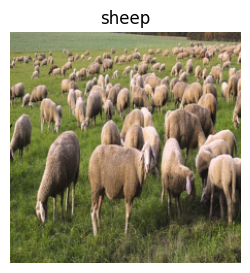

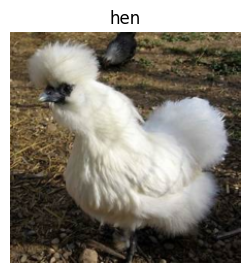

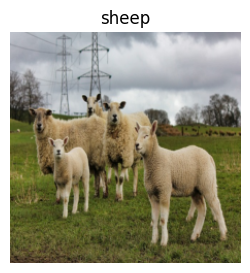

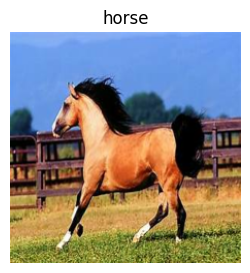

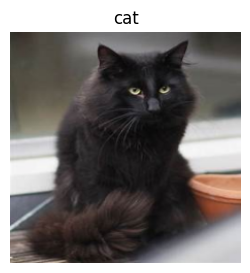

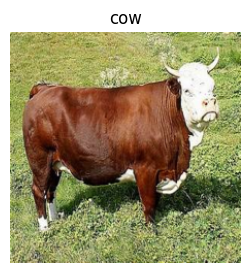

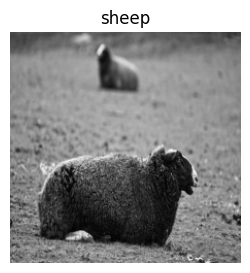

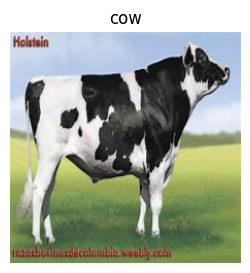

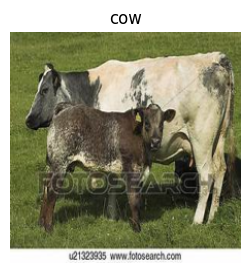

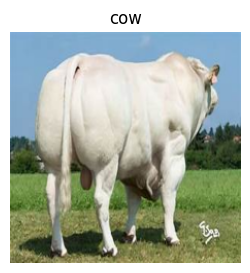

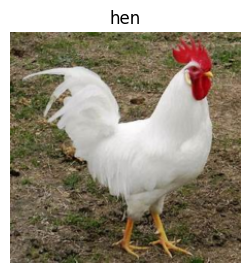

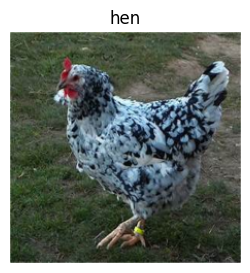

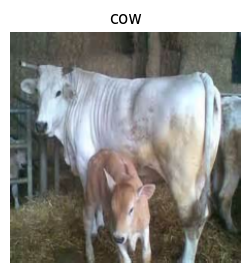

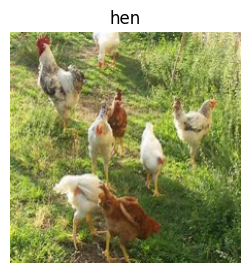

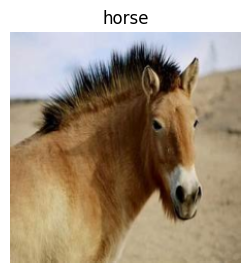

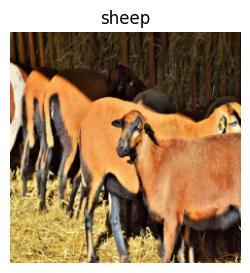

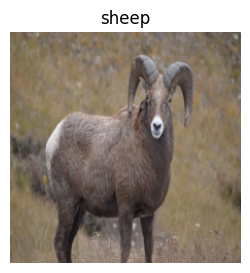

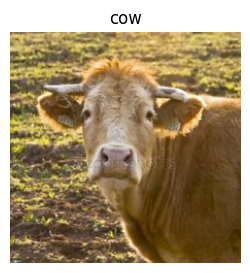

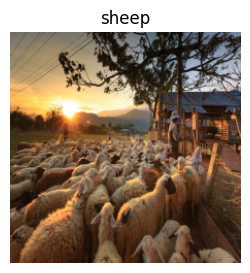

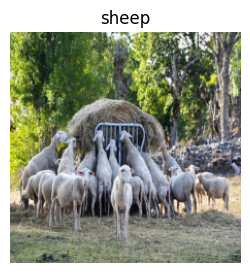

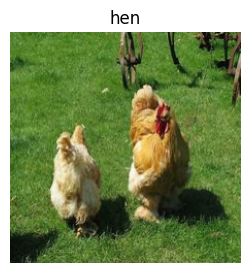

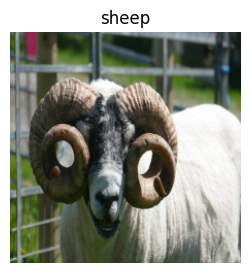

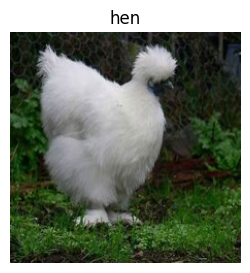

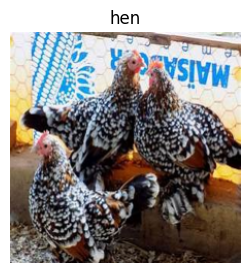

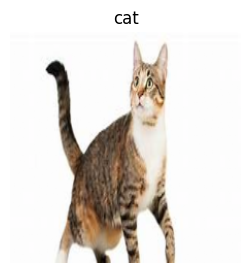

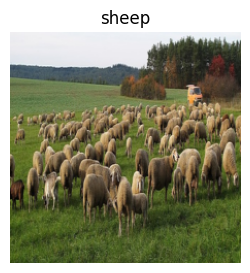

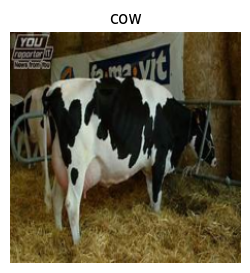

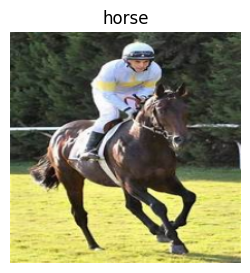

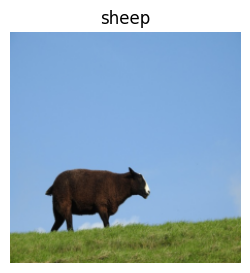

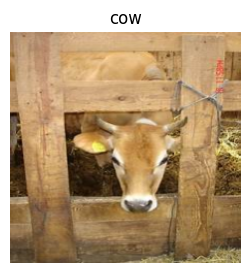

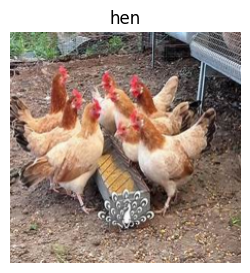

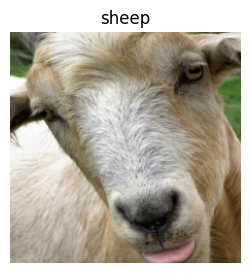

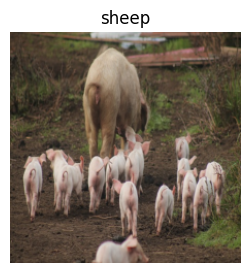

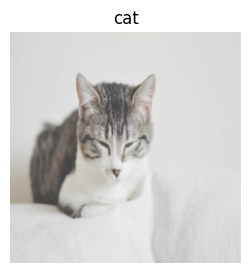

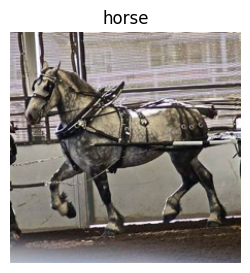

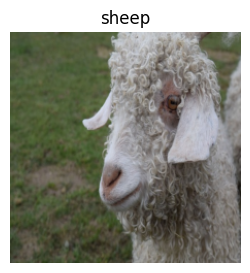

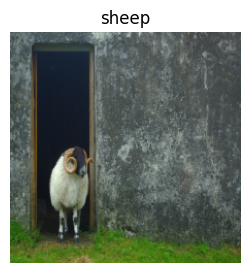

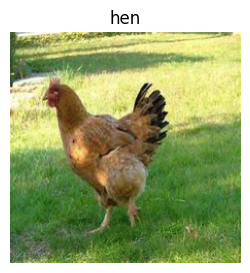

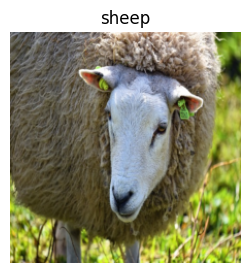

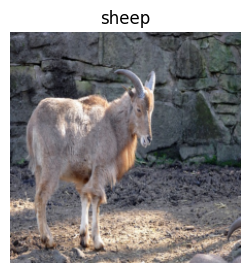

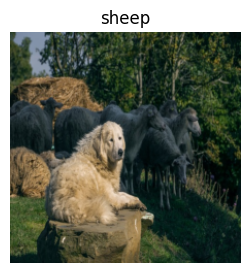

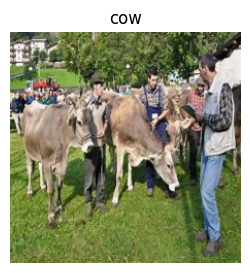

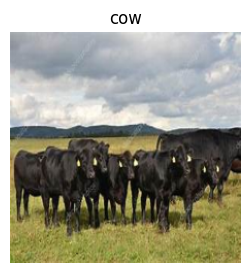

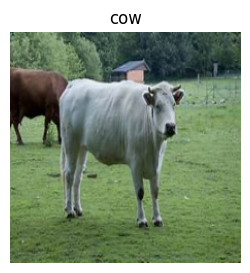

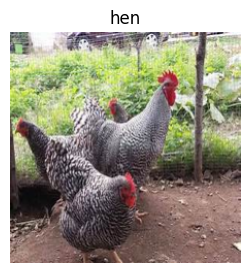

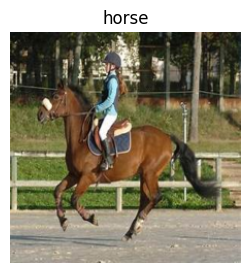

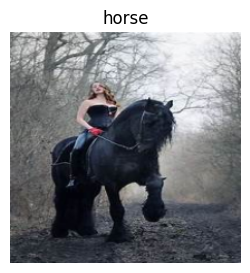

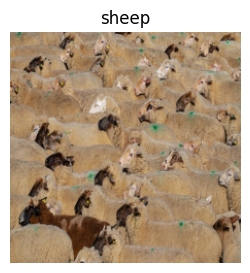

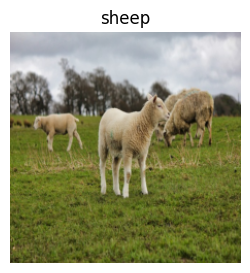

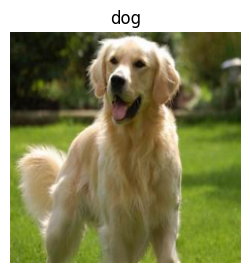

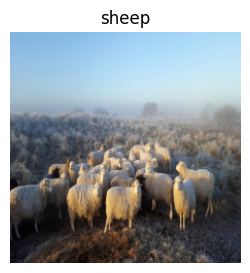

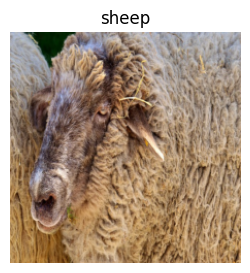

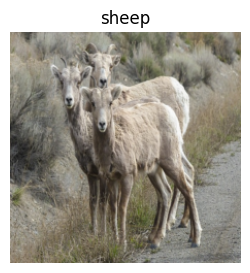

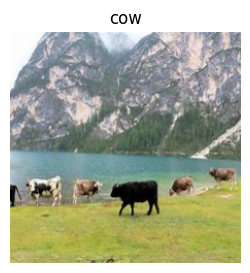

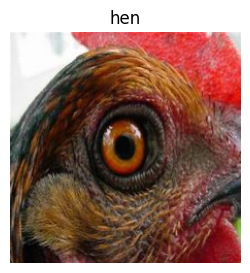

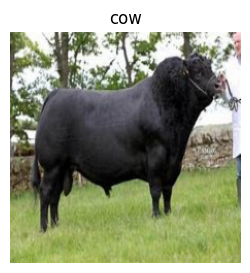

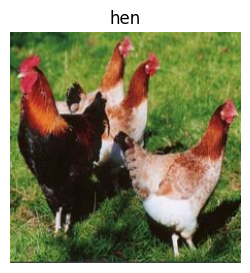

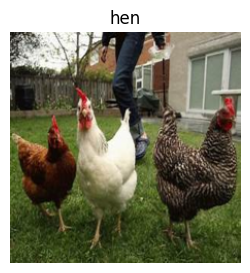

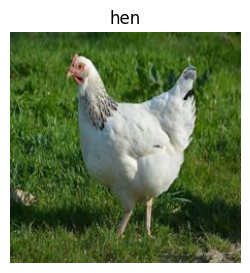

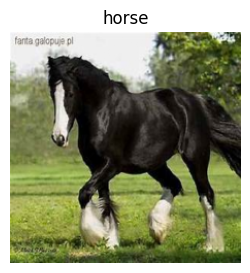

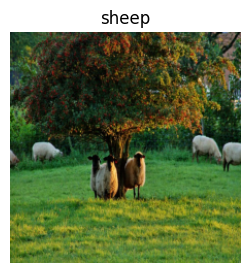

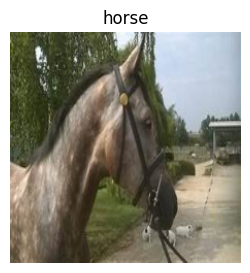

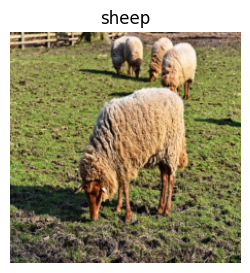

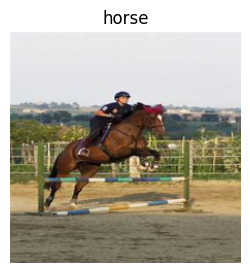

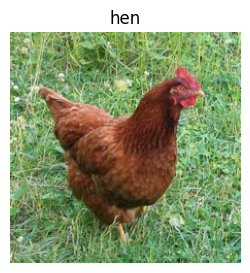

In [ ]:
model.eval()
predicted_classes = {}
with torch.no_grad():
    for images in data_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        batch_predictions = [classes[p.item()] for p in predicted][0]
        if batch_predictions not in predicted_classes:
          predicted_classes[batch_predictions] = 0
        else:
          predicted_classes[batch_predictions] += 1

        plt.figure(figsize=(3, 3))
        imshow(images[0].cpu())
        plt.title(batch_predictions)
        plt.show()

In [ ]:
print(predicted_classes)

{'horse': 27, 'cow': 58, 'sheep': 76, 'hen': 46, 'cat': 3, 'dog': 6}
